In [33]:
# Base Python imports
from PIL import Image
from pathlib import Path

# Third-party imports
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms

In [34]:
# Define dataset class for cats and dogs binary classification
class CatsDogsDataset(Dataset):
    def __init__(self, root_dir, transform=None):

        assert Path(root_dir).exists(), f"Root directory {root_dir} does not exist"
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = [p for p in Path(root_dir).glob('**/*.jpg')]
        self.labels = [1 if 'dog' in p.name else 0 for p in self.image_paths]
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path)
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label

In [35]:
def get_transforms(image_size=224, is_training=True):
    """
    Get image transforms for Vision Transformer.
    
    Args:
        image_size (int): Size to resize images to (default: 224)
        is_training (bool): Whether to use training transforms with augmentation
        
    Returns:
        transforms.Compose: Composition of image transforms
    """
    if is_training:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                              std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                              std=[0.229, 0.224, 0.225])
        ])
    
def unnormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """
    Un-normalize a tensor image with mean and standard deviation.
    
    Args:
        tensor (torch.Tensor): Tensor image of size (C, H, W)
        mean (sequence): Sequence of means for each channel
        std (sequence): Sequence of standard deviations for each channel
        
    Returns:
        torch.Tensor: Un-normalized tensor
    """
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor 

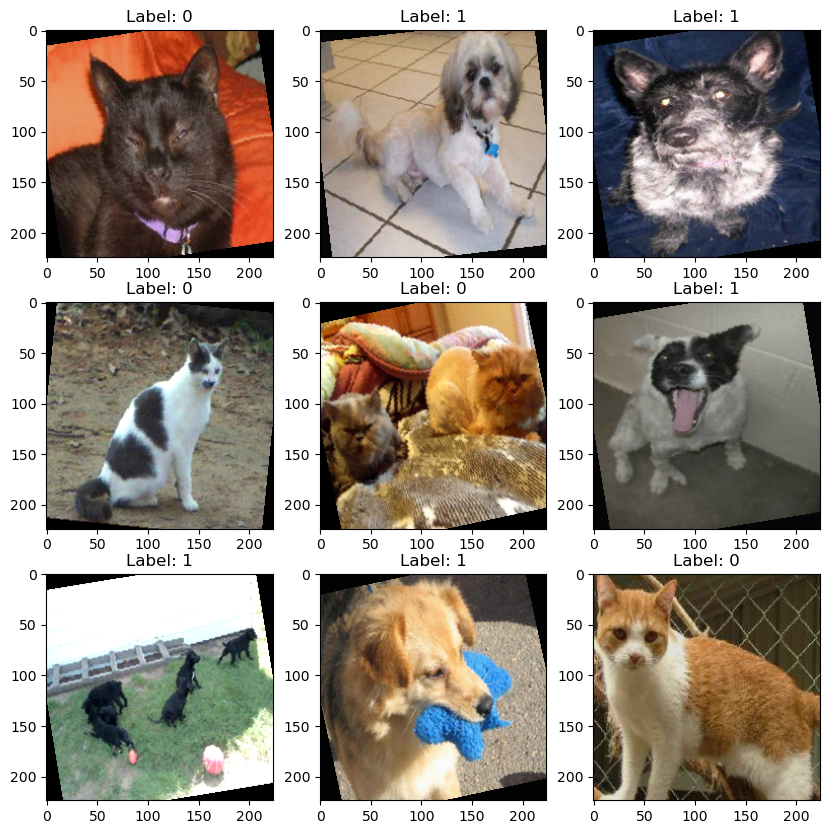

In [36]:
# Define a function to plot images and labels from the dataset
def plot_images_and_labels(dataset):
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    for i in range(9):
        r = i // 3
        c = i % 3
        image, label = dataset[i]
        image = unnormalize(image)
        axes[r, c].imshow(image.permute(1, 2, 0))
        axes[r, c].set_title(f"Label: {label}")
    plt.show()


train_transform = get_transforms(image_size=224, is_training=True)
val_transform = get_transforms(image_size=224, is_training=False)

# Define the training and validation datasets
train_dataset = CatsDogsDataset(root_dir='/home/ben/data/dogs-vs-cats/train/', transform=train_transform)
val_dataset = CatsDogsDataset(root_dir='/home/ben/data/dogs-vs-cats/test1/', transform=val_transform)

# Test the plotting function
plot_images_and_labels(train_dataset)


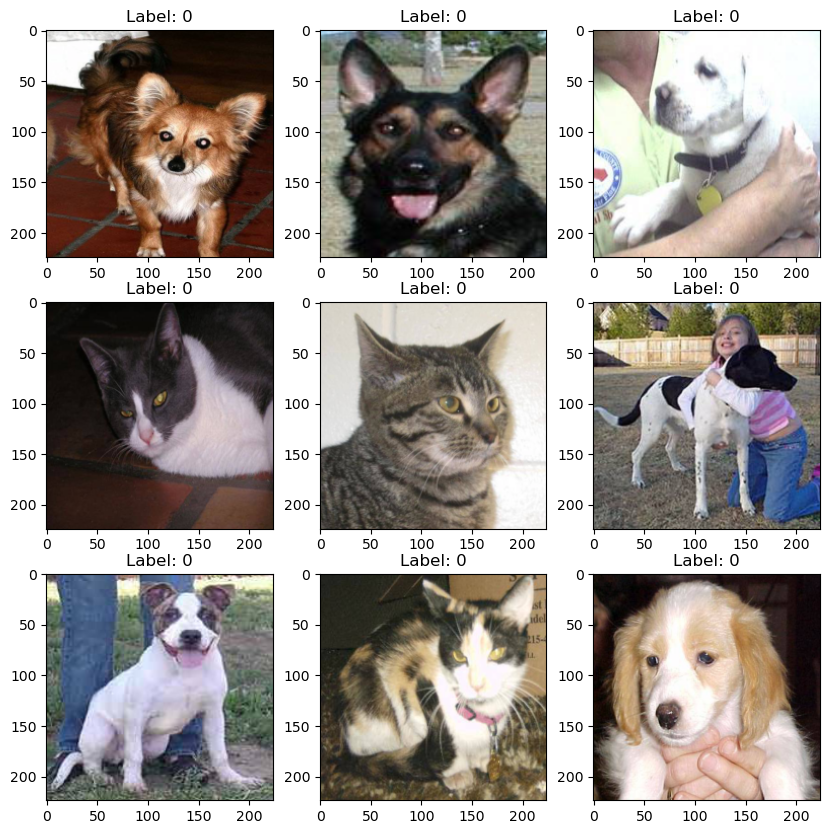

In [37]:
# Plot some of the validation images
plot_images_and_labels(val_dataset)

In [39]:
# Define the dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

## Plan of attack

### 1. Define a class to embed the image patches
- Each patch is a 16x16x3 image.
- We want to embed each patch into a 1024-dimensional space.
    - The input into the embedding layer is a $ (num \ images, num \ patches, patch \ size \times patch \ size \times 3) $ tensor.
- We will use a linear layer to embed the patches.
- We will also add a positional encoding to the patches.
- The input to the class is a 224x224x3 image.

### 2. Define a class to pass the patches through a transformer encoder
- Define an attention layer
### 3. Define a class to take the embedded patches and pass them through a classifier
### 4. Define a class to combine the above into a single model
### 5. Define a training loop and train the model (include logging, plotting, saving, etc.)


In [ ]:
# Define a class to embed the image patches
class ImagePatches(nn.Module):
    def __init__(self, image_size=224, patch_size=16, embed_dim=1024, device='cuda'):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.position = torch.arange(self.num_patches, device=device)
        self.patch_embed = nn.Linear(patch_size * patch_size * 3, embed_dim)
        self.pos_embed = nn.Embedding(num_embeddings=self.num_patches, embedding_dim=embed_dim)
        

    def forward(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed(self.position)
        return x

# Define an Encoder class
class Encoder(nn.Module):
    def __init__(self, embed_dim=1024, ff_dim=4096, num_heads=16, device='cuda'):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.device = device

        # Define query, key, value
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)

        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim, 
            num_heads=num_heads, 
            batch_first=True, 
            device=device
            )
        
        self.dropout1 = nn.Dropout(0.1)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim),
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout2 = nn.Dropout(0.1)


    def forward(self, x):
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)
        x = self.attention(q, k, v)


        # Calculate attention
        attention, _ = self.attention(
            q, k, v,
            need_weights=False,
            )
        
        # Apply dropout to attention
        attention_out = self.dropout1(attention)

        # Add and normalize per Attention is all you need
        attention_out = self.norm1(x + attention_out)

        # Pass attention with residual to linear stack
        feed_forward_out = self.mlp(attention_out)
        feed_forward_out = self.dropout2(feed_forward_out)

        # Add and Normalize
        block_out = self.norm2(attention_out + feed_forward_out)
        
        return block_out
